In [1]:
pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.7 MB/s eta 0:00:00


In [2]:
import cv2
from pathlib import Path
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [ ]:
#image_folder = Path("/content/images")
#image_paths = list(Path(image_folder).glob("*.JPG"))

In [4]:
video_folder = Path("/content/videos")
video_paths = list(Path(video_folder).glob("*.mp4"))

In [5]:
model1 = YOLO("yolov8x.pt")

In [6]:
results = model1.predict(source= video_folder, save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 handbag, 1 cell phone, 73.5ms
video 1/1 (frame 2/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 cell phone, 11.5ms
video 1/1 (frame 3/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 cell phone, 11.1ms
video 1/1 (frame 4/103) /content/videos/IMG_1891.MP4: 640x512 13 persons, 1 handbag, 1 cell phone, 10.7ms
video 1/1 (frame 5/103) /content/videos/IMG_1891.MP4: 64

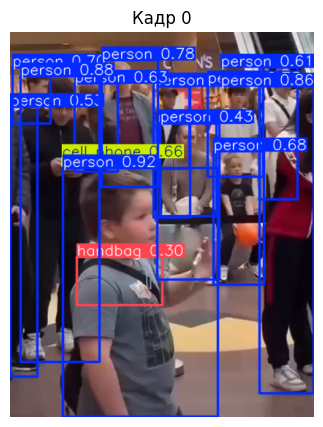

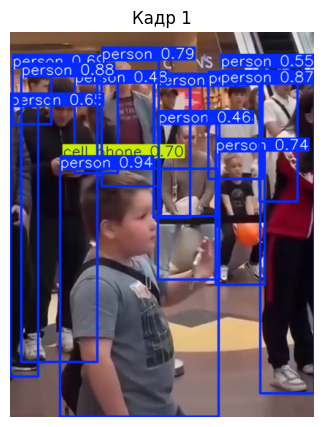

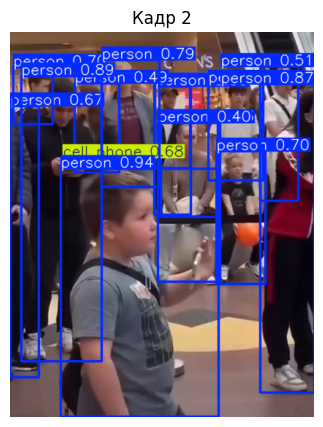

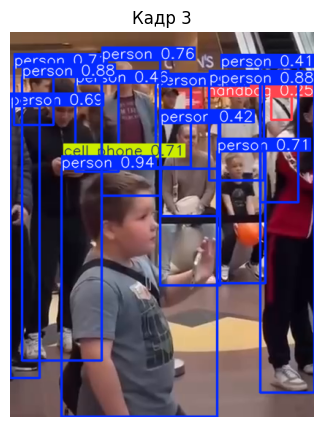

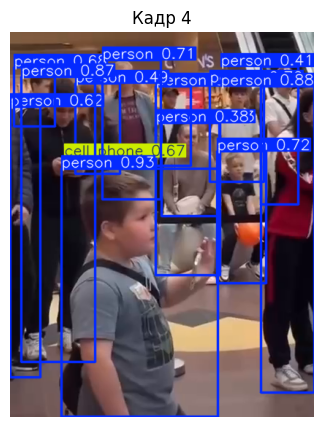

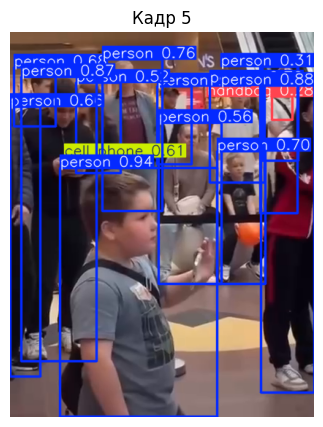

In [7]:
for i, r in enumerate(results[:6]):
    im_bgr = r.plot()
    im_rgb = im_bgr[:, :, ::-1]

    plt.figure(figsize=(10, 5))
    plt.imshow(im_rgb)
    plt.title(f"Кадр {i}")
    plt.axis('off')
    plt.show()

In [8]:
results = model1.predict(source='/content/videos', conf=0.25, save=True)
for result in results:
    if len(result.boxes) > 0:
        confidences = result.boxes.conf.tolist()
        for i, conf in enumerate(confidences):
            print(f"Объект {i+1}: Точность (Confidence) = {conf:.2%}")
    else:
        print("Объекты не найдены")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 handbag, 1 cell phone, 11.8ms
video 1/1 (frame 2/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 cell phone, 11.1ms
video 1/1 (frame 3/103) /content/videos/IMG_1891.MP4: 640x512 14 persons, 1 cell phone, 11.0ms
video 1/1 (frame 4/103) /content/videos/IMG_1891.MP4: 640x512 13 persons, 1 handbag, 1 cell phone, 11.2ms
video 1/1 (frame 5/103) /content/videos/IMG_1891.MP4: 64

In [9]:
metrics = model1.val(data='coco8.yaml')
print(f"Средняя точность (mAP50-95): {metrics.box.map:.2%}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 4.2Kfiles/s 0.0s
Dataset download success ✅ (0.3s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1151.2±488.0 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.3Kit/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all          4         17      0.842       0.95      0.977      0.773
                person          3         10          1      0.712      0.889      0.644
                   dog          1          1       0.8

In [ ]:
#HAGGING FACE

In [35]:
import cv2
import torch
import pandas as pd
from PIL import Image
from transformers import DetrImageProcessor, DetrForObjectDetection

In [28]:
pip install transformers torch opencv-python pillow


In [45]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", revision="no_timm")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50", revision="no_timm")


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

In [46]:
input_video = "/content/videos/IMG_1891.MP4"
output_video = "/content/output_video.mp4"
output_csv = "/content/detections.csv"

In [53]:
cap = cv2.VideoCapture(input_video)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

In [54]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

In [55]:
results = []
frame_count = 0

In [56]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs)

    # порог уверенности 0.9
    target_sizes = torch.tensor([image.size[::-1]])
    detections = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.9)[0]

    for score, label, box in zip(detections["scores"], detections["labels"], detections["boxes"]):
        box = box.tolist()
        results.append({
            'frame': frame_count,
            'label': model.config.id2label[label.item()],
            'score': score.item(),
            'xmin': box[0],
            'ymin': box[1],
            'xmax': box[2],
            'ymax': box[3]
        })
        xmin, ymin, xmax, ymax = map(int, box)
        cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(frame, f"{model.config.id2label[label.item()]}: {score:.2f}",
                    (xmin, ymin-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    out.write(frame)
    frame_count += 1

In [57]:
cap.release()
out.release()

# Сохраняем CSV
pd.DataFrame(results).to_csv(output_csv, index=False)

print(f"Обработано кадров: {frame_count}")
print(f"Видео с детекцией: {output_video}")
print(f"CSV файл: {output_csv}")

Обработано кадров: 103
Видео с детекцией: /content/output_video.mp4
CSV файл: /content/detections.csv
